In [46]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')

PyTorch version : 2.10.0+cu128
GPU available   : True


In [47]:
# Cell 2 — Load dataset
df = pd.read_csv('/kaggle/input/datasets/manisha1prakash/marathi-dataset-dm/Marathi_DM_Proj.csv')

df['label'] = df['label'].astype(str).str.strip()
df['label'] = df['label'].map({'1': 'Happy', '0': 'Neutral', '-1': 'Sad'})

print(f'Dataset Shape: {df.shape}')
print(f'\nLabel Distribution:')
print(df['label'].value_counts())
print(f'\nSample rows:')
display(df.head(10))

Dataset Shape: (1500, 2)

Label Distribution:
label
Happy      500
Neutral    500
Sad        500
Name: count, dtype: int64

Sample rows:


,tweet,label
0,कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदी...,Happy
1,पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यां...,Happy
2,"पुणे येथील ""क्रांती ज्योती"" या कार्यक्रमात ज...",Neutral
3,आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनि...,Happy
4,महाराष्ट्राचे मुख्यमंत्री म्हणून शपथ घेतल्या...,Happy
5,अधुनिक भारताचे पहिले समाजक्रांतिकारक महात्मा...,Happy
6,दीपावली लक्ष्मीपूजनानिमित्त आज परळी शहरातील ...,Happy
7,महाराष्ट्र खऱ्या अर्थाने हागणदारीमुक्त व्हाव...,Sad
8,"Wishing everyone a very prosperous, healthy ...",Happy
9,औरंगाबाद मध्य विधानसभा मतदार संघामध्ये अब्दु...,Neutral


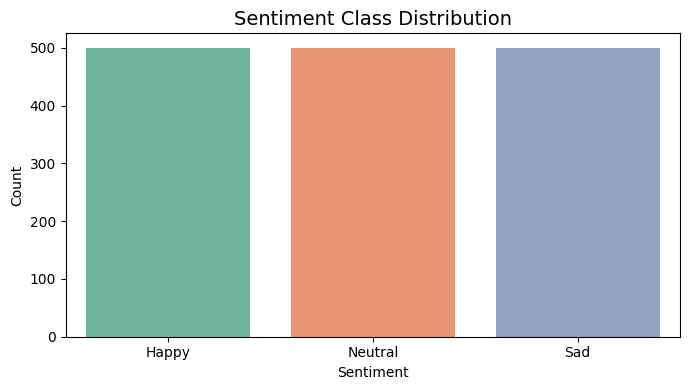

In [48]:
# Cell 3 — Plot class distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='label', hue='label',
              order=['Happy', 'Neutral', 'Sad'],
              palette='Set2', legend=False)
plt.title('Sentiment Class Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [49]:
# Cell 4 — Encode labels and split dataset
#
# FIX: Use an explicit label ordering instead of relying on LabelEncoder's
# alphabetical sort. This ensures the index→label mapping is always correct
# and predictions at inference time are never mislabelled.
#
LABEL_ORDER = ['Happy', 'Neutral', 'Sad']   # index 0, 1, 2
label2id    = {lbl: idx for idx, lbl in enumerate(LABEL_ORDER)}
id2label    = {idx: lbl for lbl, idx in label2id.items()}
label_names = LABEL_ORDER                   # used by classification_report etc.
num_labels  = len(label_names)

print(f'Label mapping : {label2id}')
print(f'Number of classes: {num_labels}')

X = df['tweet'].tolist()
y = [label2id[lbl] for lbl in df['label']]

# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'\nSplit → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Label mapping : {'Happy': 0, 'Neutral': 1, 'Sad': 2}
Number of classes: 3

Split → Train: 1050, Val: 225, Test: 225


In [50]:
# Cell 5 — Dataset class
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

print('Dataset class ready!')

Dataset class ready!


In [51]:
# Cell 6 — MuRIL + CNN Hybrid Model (FIXED Architecture)
#
# KEY FIX: The original model threw away the [CLS] token and used ONLY CNN
# features, which forced the model to re-learn everything from scratch and
# lost MuRIL's pretrained sentence-level representation.
#
# This version CONCATENATES:
#   • [CLS] token vector  (768-dim) — global sentence meaning from MuRIL
#   • CNN MaxPool features (384-dim) — local n-gram patterns
# giving the classifier the best of both worlds.

class MuRILWithCNN(nn.Module):
    """
    MuRIL encoder  →  [CLS] vector  +  CNN n-gram features  →  FC classifier

    Architecture:
      1. MuRIL encoder  → token embeddings [B, seq_len, 768]
      2. [CLS] token    → global sentence vector [B, 768]
      3. Parallel Conv1d (kernel 3,4,5) over all tokens → local n-gram features
      4. MaxPool over time → fixed-length CNN vector [B, num_filters * 3]
      5. Concat [CLS + CNN] → Dropout → FC → num_labels logits
    """
    def __init__(self, model_name, num_labels,
                 num_filters=256, kernel_sizes=(3, 4, 5), dropout=0.4):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size   # 768 for MuRIL-base

        # Parallel Conv1d branches (larger kernels capture longer n-grams)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=hidden,
                      out_channels=num_filters,
                      kernel_size=k,
                      padding=0)
            for k in kernel_sizes
        ])
        self.relu        = nn.ReLU()
        self.dropout     = nn.Dropout(dropout)

        # Input dim = [CLS] (768) + CNN features (num_filters * num_kernels)
        cnn_out_dim      = num_filters * len(kernel_sizes)
        combined_dim     = hidden + cnn_out_dim    # 768 + 768 = 1536
        self.layer_norm  = nn.LayerNorm(combined_dim)
        self.fc          = nn.Linear(combined_dim, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        # ── Transformer encoder ──────────────────────────────────────────
        enc_out      = self.encoder(input_ids=input_ids,
                                    attention_mask=attention_mask)
        hidden_states = enc_out.last_hidden_state      # [B, seq_len, 768]

        # ── [CLS] global representation ─────────────────────────────────
        cls_vec = hidden_states[:, 0, :]               # [B, 768]

        # ── CNN local n-gram features ────────────────────────────────────
        x = hidden_states.permute(0, 2, 1)             # [B, 768, seq_len]
        cnn_pooled = []
        for conv in self.convs:
            c = self.relu(conv(x))                     # [B, num_filters, seq-k+1]
            c = c.max(dim=2).values                    # [B, num_filters]
            cnn_pooled.append(c)
        cnn_vec = torch.cat(cnn_pooled, dim=1)         # [B, num_filters*3]

        # ── Combine & classify ────────────────────────────────────────────
        combined = torch.cat([cls_vec, cnn_vec], dim=1) # [B, 1536]
        combined = self.layer_norm(combined)
        combined = self.dropout(combined)
        logits   = self.fc(combined)                    # [B, num_labels]

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return type('Output', (), {'loss': loss, 'logits': logits})()

print('MuRILWithCNN (fixed) model class defined!')

MuRILWithCNN (fixed) model class defined!


In [52]:
# Cell 7 — Train and Evaluate helper functions
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in dataloader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)

        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask, labels=lbls)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += out.loss.item()
        preds = torch.argmax(out.logits, dim=1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)
    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in dataloader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['labels'].to(device)

            out = model(input_ids=ids, attention_mask=mask, labels=lbls)
            total_loss += out.loss.item()
            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(dataloader), acc, f1, all_preds, all_labels

print('Helper functions ready!')

Helper functions ready!


In [53]:
# Cell 8 — Run MuRIL + CNN (fixed)
#
# FIXES applied here:
#   1. Differential learning rates: MuRIL encoder gets 2e-5 (preserve pretrained
#      weights); CNN head gets 1e-3 (train from scratch faster)
#   2. MuRIL frozen for first 3 epochs — lets CNN head stabilise before
#      joint fine-tuning begins, preventing gradient interference
#   3. Batch size 16 for more stable gradient estimates
#   4. num_filters=256, kernels=(3,4,5) for richer CNN features
#   5. dropout=0.4 to reduce overfitting

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_NAME    = 'google/muril-base-cased'
DISPLAY_NAME  = 'MuRIL_CNN_Fixed'
EPOCHS        = 30
FREEZE_EPOCHS = 3      # freeze MuRIL encoder for first N epochs
BATCH_SIZE    = 16
MAX_LEN       = 128

print(f"\n{'='*60}")
print(f'  Running : {DISPLAY_NAME}')
print(f'  Model ID: {MODEL_NAME}')
print(f"{'='*60}")
print(f'  Device  : {device}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = MuRILWithCNN(
    model_name   = MODEL_NAME,
    num_labels   = num_labels,
    num_filters  = 256,
    kernel_sizes = (3, 4, 5),
    dropout      = 0.4
)
model.to(device)

use_gpu  = device.type == 'cuda'
train_dl = DataLoader(EmotionDataset(X_train, y_train, tokenizer, MAX_LEN),
                      batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, pin_memory=use_gpu)
val_dl   = DataLoader(EmotionDataset(X_val,   y_val,   tokenizer, MAX_LEN),
                      batch_size=BATCH_SIZE,
                      num_workers=0, pin_memory=use_gpu)
test_dl  = DataLoader(EmotionDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                      batch_size=BATCH_SIZE,
                      num_workers=0, pin_memory=use_gpu)

# ── Differential learning rates ──────────────────────────────────────────────
# MuRIL encoder: low LR to avoid catastrophic forgetting of pretrained weights
# CNN + FC head: high LR since weights are randomly initialised
optimizer = AdamW([
    {'params': model.encoder.parameters(),    'lr': 2e-5},
    {'params': model.convs.parameters(),      'lr': 1e-3},
    {'params': model.layer_norm.parameters(), 'lr': 1e-3},
    {'params': model.fc.parameters(),         'lr': 1e-3},
], weight_decay=0.01)

total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = total_steps // 10,
    num_training_steps= total_steps
)

# ── Freeze MuRIL encoder for first FREEZE_EPOCHS ─────────────────────────────
print(f'\n  Freezing MuRIL encoder for first {FREEZE_EPOCHS} epochs...')
for param in model.encoder.parameters():
    param.requires_grad = False

best_val_acc, best_state = 0, None
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):

    # Unfreeze MuRIL after warmup phase
    if epoch == FREEZE_EPOCHS + 1:
        print(f'\n  >> Epoch {epoch}: Unfreezing MuRIL encoder for joint fine-tuning...')
        for param in model.encoder.parameters():
            param.requires_grad = True

    tr_loss, tr_acc               = train_epoch(model, train_dl, optimizer, scheduler, device)
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_dl, device)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    marker = ' ✅ best' if vl_acc > best_val_acc else ''
    print(f'  Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  F1: {vl_f1:.4f}{marker}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}

print('\n✅ Training complete.')
print(f'   Best Val Accuracy: {best_val_acc:.4f}')


  Running : MuRIL_CNN_Fixed
  Model ID: google/muril-base-cased
  Device  : cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Freezing MuRIL encoder for first 3 epochs...
  Epoch 01/30 | Train Loss: 1.1014  Acc: 0.3943 | Val Loss: 0.9692  Acc: 0.4089  F1: 0.3103 ✅ best
  Epoch 02/30 | Train Loss: 0.7959  Acc: 0.6638 | Val Loss: 0.6700  Acc: 0.7511  F1: 0.7446 ✅ best
  Epoch 03/30 | Train Loss: 0.5977  Acc: 0.7505 | Val Loss: 0.5882  Acc: 0.7200  F1: 0.7157

  >> Epoch 4: Unfreezing MuRIL encoder for joint fine-tuning...
  Epoch 04/30 | Train Loss: 0.4292  Acc: 0.8324 | Val Loss: 0.5478  Acc: 0.7689  F1: 0.7689 ✅ best
  Epoch 05/30 | Train Loss: 0.2397  Acc: 0.9133 | Val Loss: 0.8029  Acc: 0.7822  F1: 0.7844 ✅ best
  Epoch 06/30 | Train Loss: 0.1197  Acc: 0.9562 | Val Loss: 0.9037  Acc: 0.7733  F1: 0.7735
  Epoch 07/30 | Train Loss: 0.0664  Acc: 0.9762 | Val Loss: 1.1433  Acc: 0.7778  F1: 0.7778
  Epoch 08/30 | Train Loss: 0.0353  Acc: 0.9867 | Val Loss: 1.3302  Acc: 0.7600  F1: 0.7533
  Epoch 09/30 | Train Loss: 0.0230  Acc: 0.9895 | Val Loss: 1.8269  Acc: 0.7556  F1: 0.7578
  Epoch 10/30 | Train Loss: 0.0

In [54]:
# Cell 9 — Evaluate on Test Set
model.load_state_dict(best_state)
_, ts_acc, ts_f1, ts_preds, ts_labels = evaluate(model, test_dl, device)

print(f'\n  Test Accuracy      : {ts_acc:.4f}')
print(f'  Test F1 (weighted) : {ts_f1:.4f}')
print(f'\n  Classification Report:')
print(classification_report(ts_labels, ts_preds, target_names=label_names))


  Test Accuracy      : 0.8711
  Test F1 (weighted) : 0.8719

  Classification Report:
              precision    recall  f1-score   support

       Happy       0.88      0.87      0.87        75
     Neutral       0.80      0.84      0.82        75
         Sad       0.94      0.91      0.93        75

    accuracy                           0.87       225
   macro avg       0.87      0.87      0.87       225
weighted avg       0.87      0.87      0.87       225



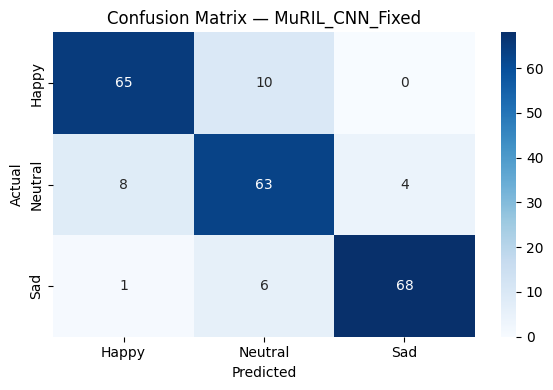

In [55]:
# Cell 10 — Confusion Matrix
cm = confusion_matrix(ts_labels, ts_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix — {DISPLAY_NAME}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'/kaggle/working/cm_{DISPLAY_NAME}.png', dpi=150)
plt.show()

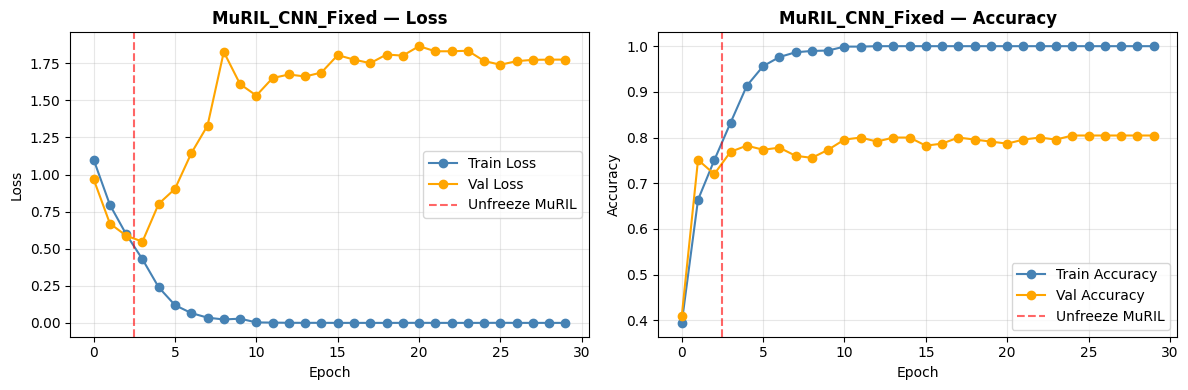

In [56]:
# Cell 11 — Training & Validation Loss and Accuracy graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], marker='o', color='steelblue', label='Train Loss')
ax1.plot(history['val_loss'],   marker='o', color='orange',    label='Val Loss')
ax1.axvline(x=FREEZE_EPOCHS - 0.5, color='red', linestyle='--', alpha=0.6, label='Unfreeze MuRIL')
ax1.set_title(f'{DISPLAY_NAME} — Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], marker='o', color='steelblue', label='Train Accuracy')
ax2.plot(history['val_acc'],   marker='o', color='orange',    label='Val Accuracy')
ax2.axvline(x=FREEZE_EPOCHS - 0.5, color='red', linestyle='--', alpha=0.6, label='Unfreeze MuRIL')
ax2.set_title(f'{DISPLAY_NAME} — Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'/kaggle/working/curve_{DISPLAY_NAME}.png', dpi=150)
plt.show()

In [57]:
# Cell 12 — Save Model
import os
safe_name  = DISPLAY_NAME.replace(' ', '_')
save_path  = f'/kaggle/working/saved_{safe_name}'
os.makedirs(save_path, exist_ok=True)

# Save the MuRIL encoder part using HuggingFace API
model.encoder.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Save the full model state dict (includes CNN + FC weights)
torch.save(model.state_dict(), f'{save_path}/full_model_state.pt')

print(f'  Saved to {save_path}')
print('  Files:', os.listdir(save_path))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
  Saved to /kaggle/working/saved_MuRIL_CNN_Fixed
  Files: ['config.json', 'tokenizer.json', 'model.safetensors', 'full_model_state.pt', 'tokenizer_config.json']


In [58]:
# Cell 13 — Sample Predictions (FIXED label mapping)
#
# FIX: Previously the code used label_names[probs.argmax()] which depends on
# LabelEncoder sort order and can silently mislabel if order shifts.
# Now we use the explicit id2label dict defined in Cell 4.

def predict_sentiment(texts, model, tokenizer, device, id2label, max_len=128):
    model.eval()
    results = []
    for text in texts:
        enc  = tokenizer(text, max_length=max_len, padding='max_length',
                         truncation=True, return_tensors='pt')
        ids  = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            out = model(input_ids=ids, attention_mask=mask)

        probs      = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        pred_idx   = int(probs.argmax())
        sentiment  = id2label[pred_idx]          # ← uses explicit dict
        confidence = probs[pred_idx] * 100

        # Show per-class probabilities for transparency
        prob_str = '  |  '.join(
            f"{id2label[i]}: {probs[i]*100:.1f}%" for i in range(len(probs))
        )
        results.append({
            'text':        text[:80] + ('...' if len(text) > 80 else ''),
            'sentiment':   sentiment,
            'confidence':  f'{confidence:.1f}%',
            'all_probs':   prob_str
        })
    return pd.DataFrame(results)


# Marathi test sentences (Happy / Neutral / Sad)
test_sentences = [
    'आज खूप आनंद झाला! हे खूप छान आहे!',                         # Happy
    'आज काहीच विशेष नाही, सगळं नेहमीसारखं आहे.',                 # Neutral
    'मला खूप दुःख होत आहे, कोणी नाही माझ्यासाठी.',               # Sad
    'हे खरोखरच अविश्वसनीय आहे!',                                  # Happy
    'आज हवामान ठीक आहे.',                                          # Neutral
]

preds_df = predict_sentiment(test_sentences, model, tokenizer, device, id2label)
print(preds_df[['text', 'sentiment', 'confidence']].to_string(index=False))
print('\n--- Per-class probabilities ---')
for _, row in preds_df.iterrows():
    print(f"  {row['text'][:50]}")
    print(f"    {row['all_probs']}")

# Free GPU memory
del model
torch.cuda.empty_cache()
print('\nDone. GPU memory cleared.')

                                       text sentiment confidence
          आज खूप आनंद झाला! हे खूप छान आहे!     Happy     100.0%
  आज काहीच विशेष नाही, सगळं नेहमीसारखं आहे.     Happy     100.0%
मला खूप दुःख होत आहे, कोणी नाही माझ्यासाठी.       Sad     100.0%
                  हे खरोखरच अविश्वसनीय आहे!     Happy      94.7%
                         आज हवामान ठीक आहे.     Happy     100.0%

--- Per-class probabilities ---
  आज खूप आनंद झाला! हे खूप छान आहे!
    Happy: 100.0%  |  Neutral: 0.0%  |  Sad: 0.0%
  आज काहीच विशेष नाही, सगळं नेहमीसारखं आहे.
    Happy: 100.0%  |  Neutral: 0.0%  |  Sad: 0.0%
  मला खूप दुःख होत आहे, कोणी नाही माझ्यासाठी.
    Happy: 0.0%  |  Neutral: 0.0%  |  Sad: 100.0%
  हे खरोखरच अविश्वसनीय आहे!
    Happy: 94.7%  |  Neutral: 5.2%  |  Sad: 0.1%
  आज हवामान ठीक आहे.
    Happy: 100.0%  |  Neutral: 0.0%  |  Sad: 0.0%

Done. GPU memory cleared.
